In [1]:
!pip install lightgbm


(1411, 29)
\ Training Random Forest...

 Random Forest Evaluation Metrics:
Accuracy:  0.9458
Precision: 0.9464
Recall:    0.9458
F1-Score:  0.9451

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.97       132
           1       0.91      0.99      0.95       109
           2       0.92      0.82      0.86        66
           3       0.97      0.94      0.96       117

    accuracy                           0.95       424
   macro avg       0.94      0.93      0.94       424
weighted avg       0.95      0.95      0.95       424



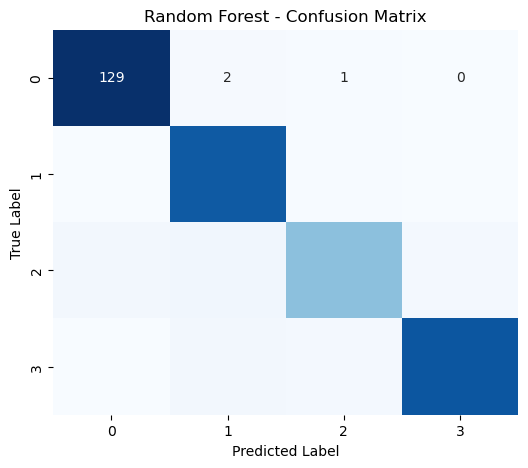

\ Training XGBoost...

 XGBoost Evaluation Metrics:
Accuracy:  0.9764
Precision: 0.9765
Recall:    0.9764
F1-Score:  0.9762

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.98      0.97       132
           1       0.97      1.00      0.99       109
           2       0.97      0.91      0.94        66
           3       1.00      0.99      1.00       117

    accuracy                           0.98       424
   macro avg       0.98      0.97      0.97       424
weighted avg       0.98      0.98      0.98       424



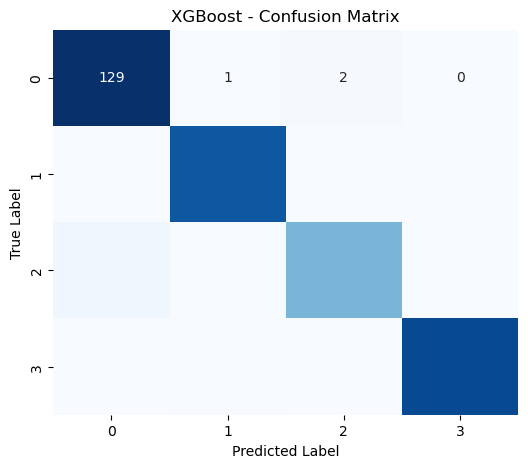

\ Training LGBMClassifier...

 LGBMClassifier Evaluation Metrics:
Accuracy:  0.9693
Precision: 0.9693
Recall:    0.9693
F1-Score:  0.9689

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.98      0.97       132
           1       0.96      0.99      0.98       109
           2       0.97      0.88      0.92        66
           3       0.98      0.99      0.99       117

    accuracy                           0.97       424
   macro avg       0.97      0.96      0.96       424
weighted avg       0.97      0.97      0.97       424



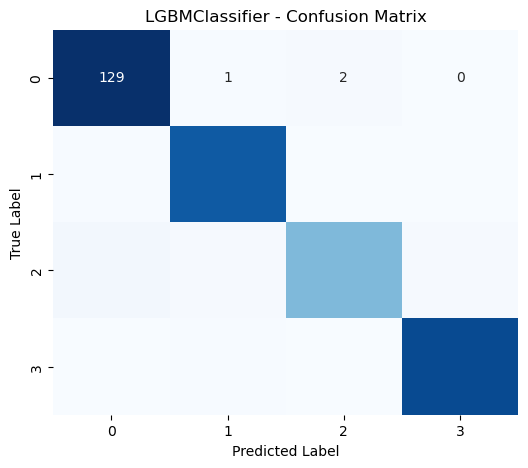

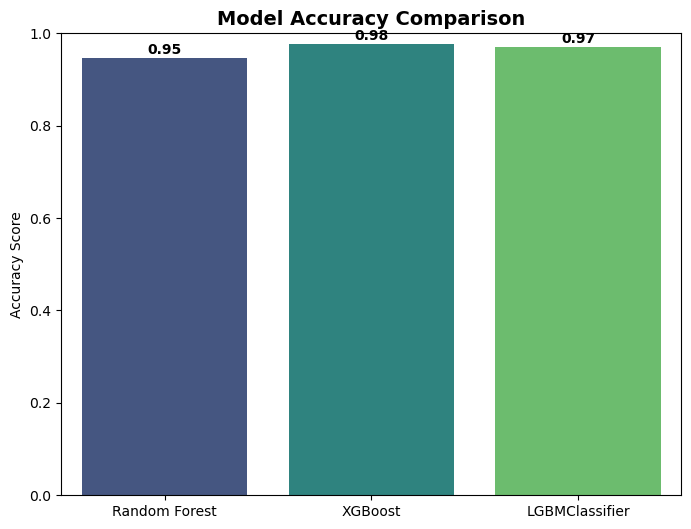

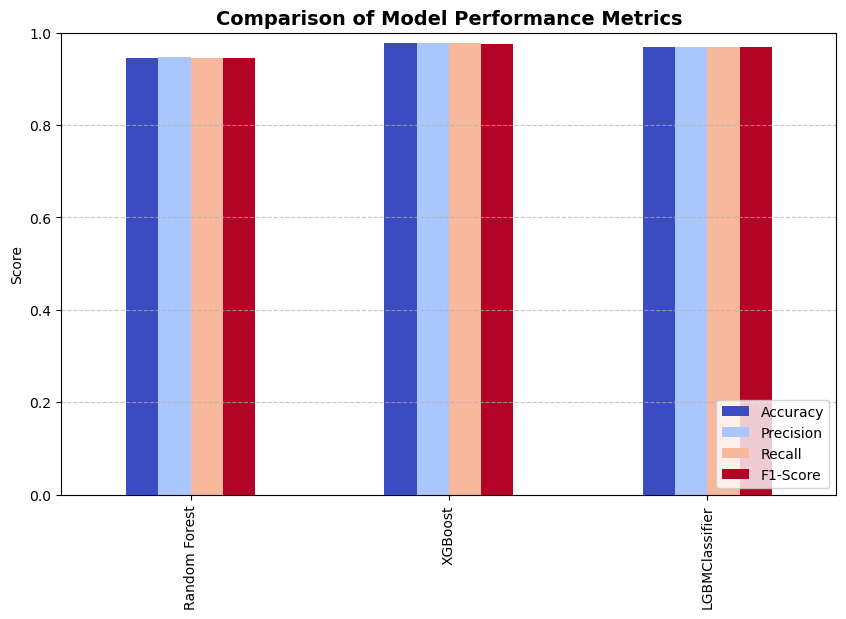


 Model Performance Summary:

                Accuracy  Precision    Recall  F1-Score
Random Forest   0.945755   0.946356  0.945755  0.945079
XGBoost         0.976415   0.976476  0.976415  0.976234
LGBMClassifier  0.969340   0.969337  0.969340  0.968944

Random Forest 5-Fold CV Accuracy: 0.9490 ± 0.0164

XGBoost 5-Fold CV Accuracy: 0.9568 ± 0.0132

LGBMClassifier 5-Fold CV Accuracy: 0.9582 ± 0.0104


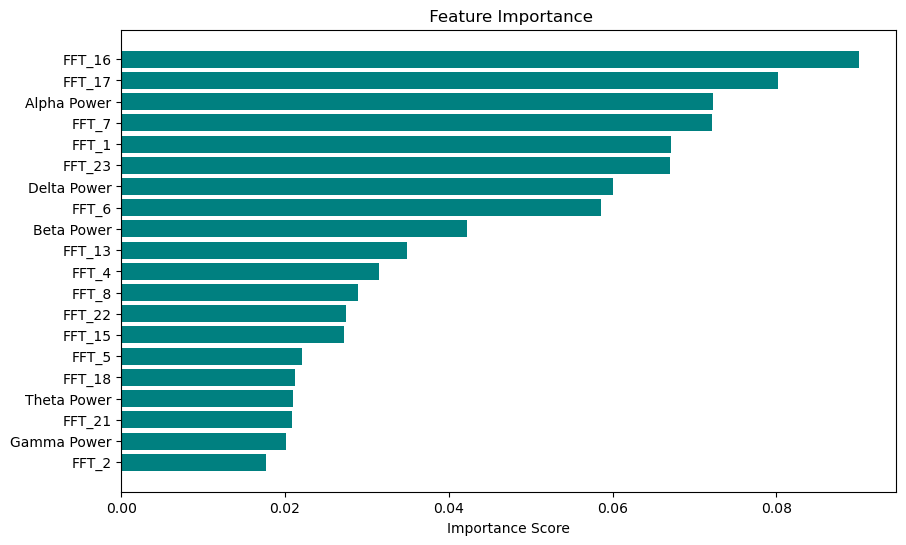

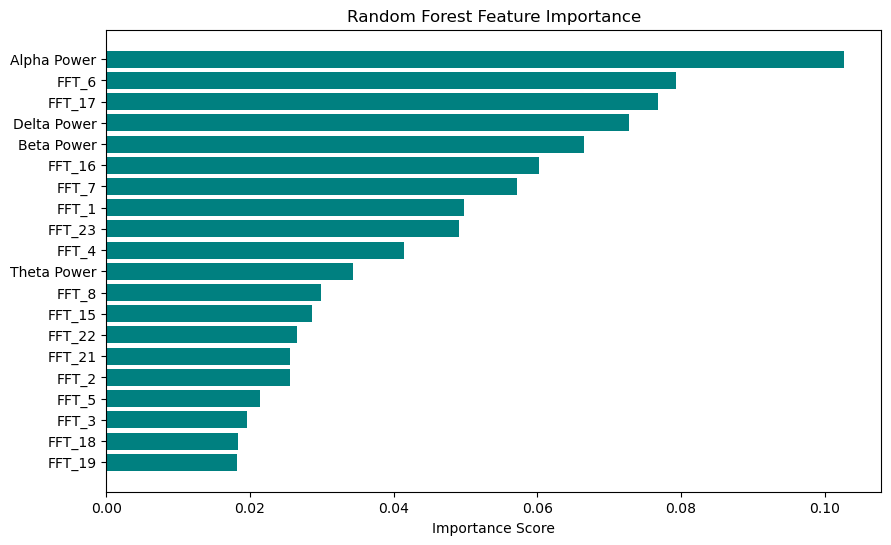


Top Selected Features: ['Alpha Power' 'Beta Power' 'Gamma Power' 'Delta Power' 'Theta Power'
 'FFT_1' 'FFT_2' 'FFT_3' 'FFT_4' 'FFT_5' 'FFT_6' 'FFT_7' 'FFT_8' 'FFT_9'
 'FFT_10' 'FFT_11' 'FFT_12' 'FFT_13' 'FFT_14' 'FFT_15' 'FFT_16' 'FFT_17'
 'FFT_18' 'FFT_19' 'FFT_20' 'FFT_21' 'FFT_22' 'FFT_23']

 Model saved successfully as 'EEG_XGBoost_Model.joblib'


In [4]:
# ================================
#  EEG Classification Project – Model Training, Testing & Validation (Final Version + Array Input)
# ================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.feature_selection import SelectKBest, f_classif
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# ----------------------------
# 1. Load Dataset
# ----------------------------
df = pd.read_excel(r"D:\miniproject\Copy of Cleaned_EEG_Dataset.xlsx")  # Use your file path
print(df.shape)

band_features = ["Alpha Power", "Beta Power", "Gamma Power", "Delta Power", "Theta Power"]
fft_features = [
    "FFT_1","FFT_2","FFT_3","FFT_4","FFT_5","FFT_6","FFT_7",
    "FFT_8","FFT_9","FFT_10","FFT_11","FFT_12","FFT_13","FFT_14",
    "FFT_15","FFT_16","FFT_17","FFT_18","FFT_19","FFT_20","FFT_21",
    "FFT_22","FFT_23"
]

feature_order = band_features + fft_features
X = df[feature_order]
y = df["Label"]

# ----------------------------
# 2. Data Preprocessing
# ----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# ----------------------------
# 3. Model Initialization
# ----------------------------
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=15, random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=500, learning_rate=0.03, max_depth=10,
        subsample=0.9, colsample_bytree=0.9, gamma=0.2,
        random_state=42, eval_metric="mlogloss"
    ),
   "LGBMClassifier": LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1   
),
}





# ----------------------------
# 4. Model Training and Evaluation
# ----------------------------
results = {}

for name, model in models.items():
    print(f"\ Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
   


    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results[name] = [acc, prec, rec, f1]

    print(f"\n {name} Evaluation Metrics:")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    # Confusion Matrix + Heatmap
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()




# ----------------------------
# 5. Accuracy Comparison – Bar Chart
# ----------------------------
results_df = pd.DataFrame(results, index=["Accuracy", "Precision", "Recall", "F1-Score"]).T

plt.figure(figsize=(8, 6))
sns.barplot(x=results_df.index, y=results_df["Accuracy"], palette="viridis")
plt.title("Model Accuracy Comparison", fontsize=14, fontweight="bold")
plt.ylabel("Accuracy Score")
plt.ylim(0, 1)
for i, v in enumerate(results_df["Accuracy"]):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center', fontweight='bold')
plt.show()

results_df.plot(kind='bar', figsize=(10, 6), colormap='coolwarm')
plt.title("Comparison of Model Performance Metrics", fontsize=14, fontweight='bold')
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("\n Model Performance Summary:\n")
print(results_df)

# ----------------------------
# 6. Cross-validation for consistency
# ----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, model in models.items():
    cv_scores = cross_val_score(model, X_scaled, y, cv=cv, scoring="accuracy")
    print(f"\n{name} 5-Fold CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# ----------------------------
# 7. Feature Importance Visualization
# ----------------------------
def plot_feature_importance(model, feature_names, top_n=20, title="Feature Importance"):
    importances = model.feature_importances_
    indices = np.argsort(importances)[-top_n:]
    plt.figure(figsize=(10, 6))
    plt.barh(range(top_n), importances[indices], align="center", color="teal")
    plt.yticks(range(top_n), [feature_names[i] for i in indices])
    plt.title(title)
    plt.xlabel("Importance Score")
    plt.show()



plot_feature_importance(models["XGBoost"], feature_order, 20, " Feature Importance")
plot_feature_importance(models["Random Forest"], feature_order, 20, "Random Forest Feature Importance")

# ----------------------------
# 8. Feature Selection Summary
# ----------------------------
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_scaled, y)
selected_features = np.array(feature_order)[selector.get_support()]
print("\nTop Selected Features:", selected_features)

# ----------------------------
# 9. Save Best Model
# ----------------------------
best_model = models["XGBoost"]  # Assuming XGBoost performed best
joblib.dump(best_model, "EEG_XGBoost_Model.joblib")
print("\n Model saved successfully as 'EEG_XGBoost_Model.joblib'")

In [5]:
# ----------------------------
#10. Array-based User Input Prediction (Forward / Backward)
# ----------------------------

# Example manual array (order must match feature_order)
# ⚠Replace the below values with your actual test sample values
user_input_array = [

360.405019, 751.9968776, 68.93350881, 714.1257821, 749.452085,  78.48053774, 313.3435658, 201.5968036, 71.97436714, 10.3144454, 9.909631706, 6.180740976, 7.531433598, 1.525352995, 1.921185721, 1.469194446, 2.338874495, 2.721124468, 4.584164512, 7.531433598, 6.180740976, 9.909631706, 10.3144454, 175.9359378, 201.5968036, 120.7048749, 313.3435658, 78.48053774


]
# Load the saved model
loaded_model = joblib.load("EEG_XGBoost_Model.joblib")

# Convert to DataFrame and scale
user_input_df = pd.DataFrame([user_input_array], columns=feature_order)
user_input_scaled = scaler.transform(user_input_df)

# Predict
pred_label = loaded_model.predict(user_input_scaled)[0]

# Decode and display
if pred_label == 0:
    print("\nPredicted Command: BACKWARD (Label = 0)")
elif pred_label == 3:
    print("\n ⬅ Predicted Command: FORWARD (Label = 3)")
elif pred_label == 2:
    print("\n ⬅ Predicted Command: RIGHT (Label = 2)")
elif pred_label == 1:
    print("\n ⬅ Predicted Command: LEFT (Label = 1)")


 ⬅ Predicted Command: LEFT (Label = 1)
